<a href="https://colab.research.google.com/github/Ann-tech2025/Robotics-Final-Year-Project/blob/main/Wav2Vec2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

# -------------------------
# Mount Google Drive
# -------------------------
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa transformers datasets soundfile

In [ ]:
from google.colab import drive
import os
import librosa
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

dataset_info = {
    "ravdess": "/content/drive/MyDrive/emotion_datasets/RAVDESS",
    "tess": "/content/drive/MyDrive/emotion_datasets/TESS",
    "crema": "/content/drive/MyDrive/emotion_datasets/CREMA",
    "savee": "/content/drive/MyDrive/emotion_datasets/SAVEE"
}


# -------------------------
# Config
# -------------------------
SAMPLE_RATE = 16000
DURATION = 3
N_MELS = 64
HOP_LENGTH = 256

# -------------------------
# Feature Extraction
# -------------------------
def extract_log_mel_spectrogram(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    audio = librosa.util.fix_length(audio, size=SAMPLE_RATE * DURATION)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    return log_mel_spec

# -------------------------
# Label Extraction
# -------------------------
def get_emotion_label(path, dataset_name):
    filename = os.path.basename(path).lower()

    if dataset_name == "ravdess":
        code = filename.split("-")[2]
        mapping = {"01":"neutral","02":"calm","03":"happy","04":"sad",
                   "05":"angry","06":"fear","07":"disgust","08":"surprise"}
        return mapping.get(code)

    elif dataset_name == "crema":
        mapping = {"ang":"angry","dis":"disgust","fea":"fear","hap":"happy","neu":"neutral","sad":"sad"}
        for key in mapping:
            if key in filename:
                return mapping[key]
        return None

    elif dataset_name == "savee":
        code = filename[:2]  # first 2 letters
        mapping = {"a":"angry","d":"disgust","f":"fear","h":"happy","n":"neutral","sa":"sad","su":"surprise"}
        return mapping.get(code, mapping.get(filename[0], None))

    elif dataset_name == "tess":
        for emo in ["angry","disgust","fear","happy","sad","surprise","neutral"]:
            if emo in filename:
                return emo
        return None

# -------------------------
# Load All Data
# -------------------------
X, y = [], []

for dataset_name, base_path in dataset_info.items():
    print(f"\nLoading {dataset_name}...")
    count = 0
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(".wav"):
                path = os.path.join(root, file)
                label = get_emotion_label(path, dataset_name)
                if label is None:
                    continue
                spec = extract_log_mel_spectrogram(path)
                X.append(spec)
                y.append(label)
                count += 1
    print(f"{dataset_name} loaded files: {count}")

# -------------------------
# Final Dataset
# -------------------------
X = np.array(X)[..., np.newaxis]  # Add channel dimension
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_cat = to_categorical(y_enc)

print("\nTotal samples:", len(y))
print("Final shape:", X.shape, y_cat.shape)
print("Classes:", le.classes_)


Loading ravdess...


In [ ]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

model.to(device)
model.eval()

def extract_embedding(audio):

    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)

    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = model(input_values)

    embedding = torch.mean(outputs.last_hidden_state, dim=1)

    return embedding.cpu().numpy()


embeddings = []

for audio in X:
    emb = extract_embedding(audio)
    embeddings.append(emb[0])

embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'X' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y_encoded, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(128, activation='relu', input_shape=(embeddings.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(emotions), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_cat
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization,
                                     Conv2D, MaxPool2D, Reshape,
                                     MultiHeadAttention, GlobalAveragePooling1D)
from tensorflow.keras.models import Model


def build_transformer_ser(input_shape, num_classes):
    inp = Input(shape=input_shape)


    # CNN Frontend

    x = Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = MaxPool2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPool2D((2,2))(x)

    # Now shape = (None, H, W, C)

    x = Reshape((x.shape[2], -1))(x)
    # shape becomes: (batch, sequence_length, embedding_dim)

    embed_dim = x.shape[-1]

    for _ in range(2):
        # Self-attention
        attn_output = MultiHeadAttention(
            num_heads=4,
            key_dim=embed_dim // 4
        )(x, x)

        x = LayerNormalization()(x + attn_output)

        # Feed-forward
        ff = Dense(128, activation='relu')(x)
        ff = Dense(embed_dim)(ff)

        x = LayerNormalization()(x + ff)


    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)
    return model


In [ ]:
model = build_transformer_ser(X.shape[1:], y_cat.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


# Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # metric to monitor
    factor=0.5,           # factor by which the learning rate will be reduced
    patience=5,           # number of epochs with no improvement before reducing
    min_lr=1e-7,          # minimum learning rate
    verbose=1
)

# Stop training when a monitored metric has stopped improving
early_stop = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=15,          # number of epochs with no improvement before stopping
    restore_best_weights=True,  # restore model weights from the epoch with the best value of the monitored metric
    verbose=1
)

# Fit the model with callbacks
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,          # or however many you plan
    batch_size=64,       # adjust as needed
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - accuracy: 0.2769 - loss: 2.0369 - val_accuracy: 0.5346 - val_loss: 1.2230 - learning_rate: 1.0000e-04
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.5237 - loss: 1.2921 - val_accuracy: 0.5595 - val_loss: 1.1778 - learning_rate: 1.0000e-04
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.5803 - loss: 1.1243 - val_accuracy: 0.5920 - val_loss: 1.0509 - learning_rate: 1.0000e-04
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.6099 - loss: 1.0194 - val_accuracy: 0.6323 - val_loss: 0.9298 - learning_rate: 1.0000e-04
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.6560 - loss: 0.9232 - val_accuracy: 0.6405 - val_loss: 0.9111 - learning_rate: 1.0000e-04
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - accuracy: 0.7018 - loss: 0.7761 - val_accuracy: 0.6740 - val_loss: 0.8531 - learning_rate: 1.0000e-04
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms

In [ ]:
# Save the complete Keras model
model.save('ser_transformer_final.h5')
print("Transformer SER model saved!")

# For Colab, download to laptop
from google.colab import files
files.download('ser_transformer_final.h5')

Transformer SER model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6915 - loss: 0.8229
Validation Loss: 0.8531, Validation Accuracy: 0.6740
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


<Figure size 1000x800 with 0 Axes>

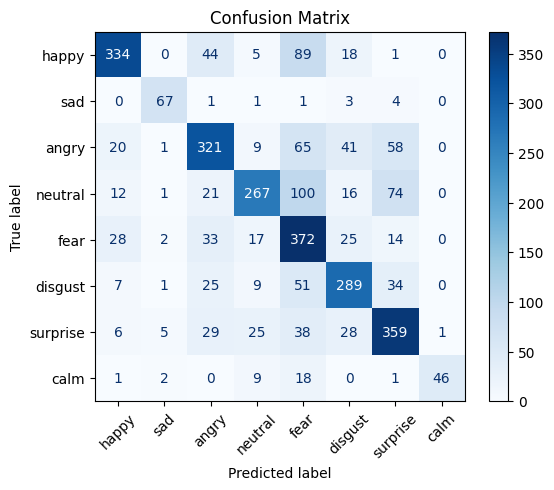

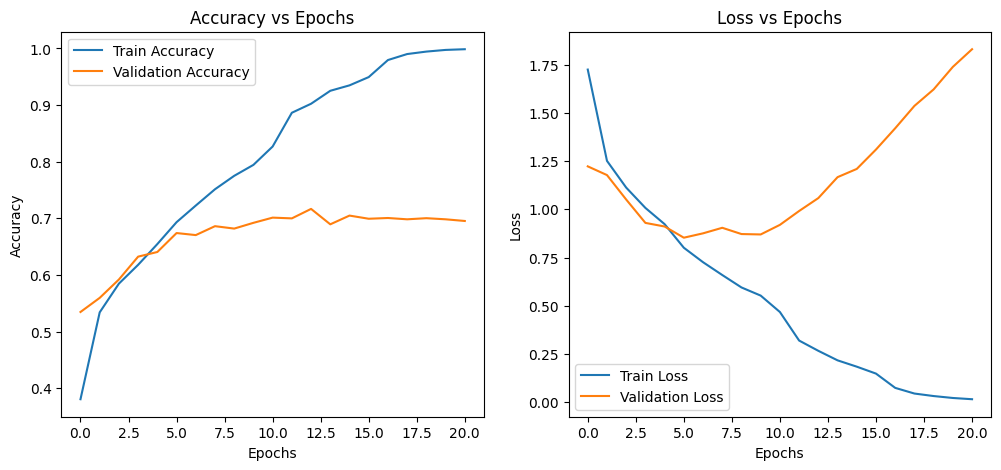

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model


# -----------------------------
# 2️⃣ Evaluate on validation/test set
# -----------------------------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

# -----------------------------
# 3️⃣ Predict classes
# -----------------------------
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)  # assuming one-hot labels

# -----------------------------
# 4️⃣ Confusion matrix
# -----------------------------
labels = ['happy', 'sad', 'angry', 'neutral', 'fear', 'disgust', 'surprise', 'calm']  # change to your 8 classes
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(10,8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 5️⃣ Plot accuracy vs loss
# -----------------------------
# Make sure you have the history object from training
# If not, you can reload training history from a file you saved
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.show()
